In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

In [35]:
df = pd.read_csv("/Titanic.csv")

In [36]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [8]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


/tmp/ipykernel_10693/3297891021.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Survived', palette='Set2', ax=axes[0])


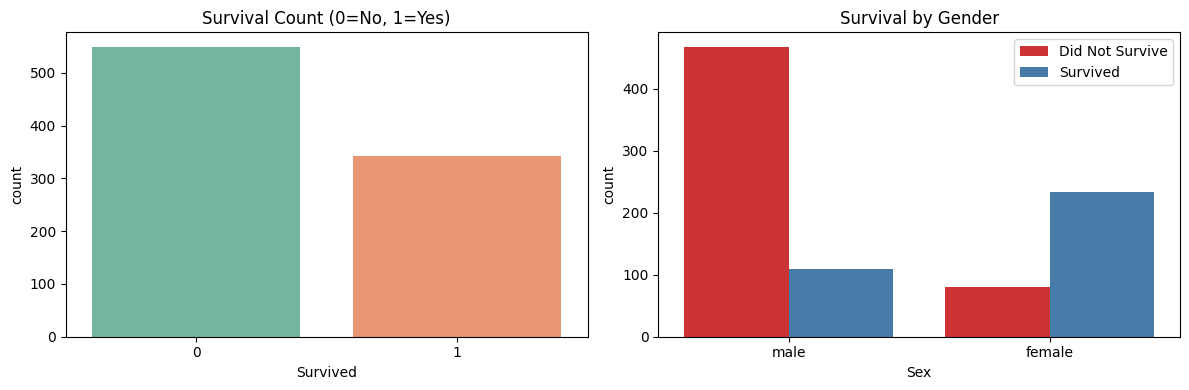

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='Survived', palette='Set2', ax=axes[0])
axes[0].set_title('Survival Count (0=No, 1=Yes)')

sns.countplot(data=df, x='Sex', hue='Survived', palette='Set1', ax=axes[1])
axes[1].set_title('Survival by Gender')
axes[1].legend(['Did Not Survive', 'Survived'])

plt.tight_layout()
plt.show()

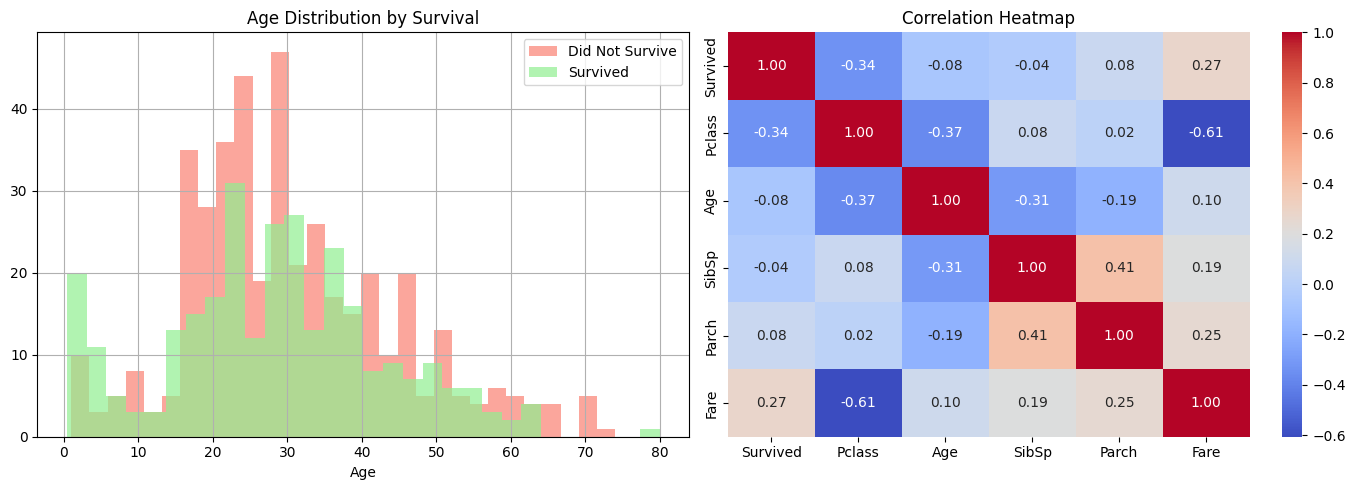

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['Survived']==0]['Age'].dropna().hist(bins=30, alpha=0.7, color='salmon', label='Did Not Survive', ax=axes[0])
df[df['Survived']==1]['Age'].dropna().hist(bins=30, alpha=0.7, color='lightgreen', label='Survived', ax=axes[0])
axes[0].set_title('Age Distribution by Survival')
axes[0].set_xlabel('Age')
axes[0].legend()

num_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1])
axes[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

/tmp/ipykernel_10693/2549846612.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Survived', y='Fare', palette='Set2', ax=axes[0])
/tmp/ipykernel_10693/2549846612.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Survived', y='Age', palette='Set1', ax=axes[1])


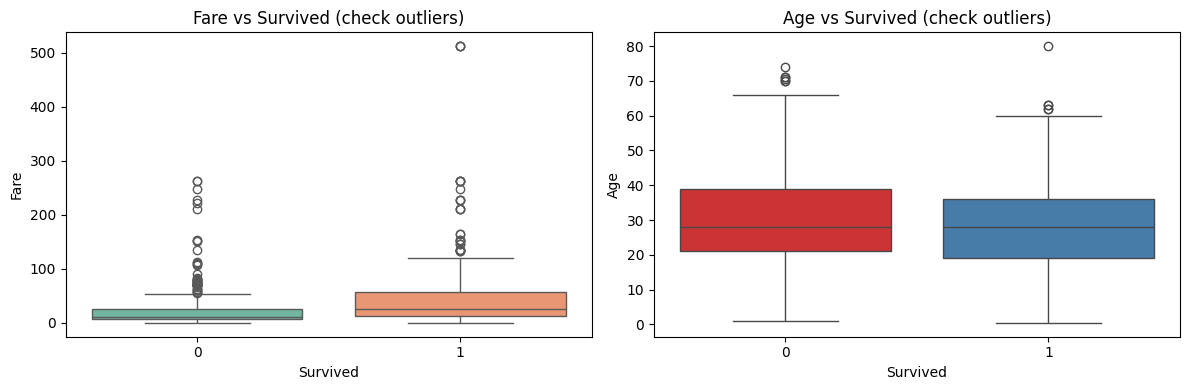

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Fare outliers
sns.boxplot(data=df, x='Survived', y='Fare', palette='Set2', ax=axes[0])
axes[0].set_title('Fare vs Survived (check outliers)')

# Age outliers
sns.boxplot(data=df, x='Survived', y='Age', palette='Set1', ax=axes[1])
axes[1].set_title('Age vs Survived (check outliers)')

plt.tight_layout()
plt.show()

In [13]:
fare_cap = df['Fare'].quantile(0.99)
df['Fare'] = df['Fare'].clip(upper=fare_cap)

print(f"Fare capped at: {fare_cap:.2f}")
print(f"Fare max now: {df['Fare'].max():.2f}")

Fare capped at: 249.01
Fare max now: 249.01


In [17]:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

In [18]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
X_train.shape

(712, 7)

In [22]:
X_test.shape

(179, 7)

In [23]:
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass']
categorical_cols = ['Sex', 'Embarked']  # OneHotEncoder
ordinal_cols = []

print("Numerical:", numerical_cols)
print("Categorical:", categorical_cols)

Numerical: ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass']
Categorical: ['Sex', 'Embarked']


In [24]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [25]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [26]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols)
])

In [27]:
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

full_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare', 'SibSp',
                                                   'Parch', 'Pclass']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [28]:
y_pred = full_pipeline.predict(X_test)

In [32]:
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print()

Accuracy : 0.8212
Precision: 0.8088
Recall   : 0.7432
F1 Score : 0.7746



In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



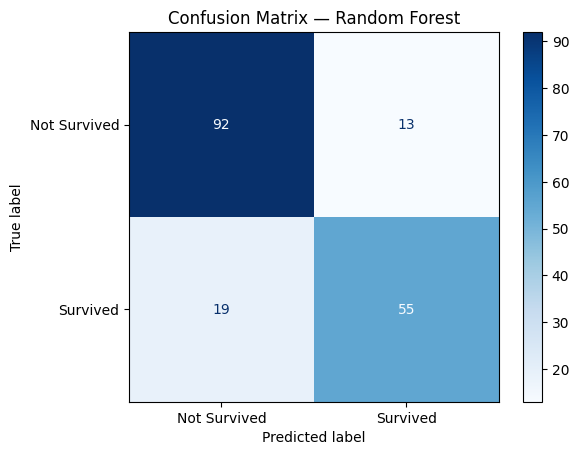

In [34]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived', 'Survived'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Random Forest')
plt.show()

## Model Interpretation

**Is the model good?**

Yes, accuracy ~82%, F1 ~0.77.
Solid baseline for Titanic dataset.

**Where does it fail?**

Some survivors predicted as dead (false negatives). Model struggles with passengers
who have unusual fare/age combinations.

**How to improve?**
- Add feature engineering: extract Title from Name (Mr/Mrs/Master)
- Tune hyperparameters: max_depth, min_samples_split
- Try XGBoost or LightGBM for better performance